# **Willkommen zur interaktiven Übung zum Thema "Pumpversuche"**

**Sebastian Gnann**


Bei Fragen und Feedback wenden Sie sich bitte an: sebastian.gnann@hydrologie.uni-freiburg.de

---

Diese Online-Übung basiert auf einem sogenannten Jupyter Notebook (https://jupyter.org/). 
Ein Notebook besteht aus einzelnen Zellen, die entweder Markdown-Text oder Python-Code beinhalten.

Bitte führen Sie das gesamte Notebook von Anfang an aus, damit alle Python-Module und die Daten in der richtigen Reihenfolge geladen werden.
Klicken Sie zunächst auf das Symbol "Restart the kernel". Dann können Sie jeden Abschnitt einzeln ausführen, indem Sie auf die entsprechende Zelle und dann auf das Symbol "Run the selected cell and advance" klicken (alternativ: Shift + Enter drücken). 
Sie können auch auf "Restart the kernel and run all cells" klicken, um das gesamte Notebook auszuführen. Dies sollte sicherstellen, dass alles in der richtigen Reihenfolge ausgeführt wird.

Nun können Sie sich Stück für Stück durch die Text- und Codezellen arbeiten. 

Sollten Sie länger inaktiv sein, kann es vorkommen, dass das Notebook nicht mehr richtig läuft (z.B. Nachricht "Kernel died unexpectedly"). Starten Sie in diesem Fall das Notebook einfach neu, am besten mit "Restart the kernel and run all cells". Sie können dann direkt zu dem Punkt zurückkehren, an dem Sie sich befanden, und müssen sich nicht erneut durch alle Zellen klicken. Sollte das Notebook gar nicht mehr laufen, dann laden Sie bitte den gesamten Link erneut.

Auf der linken Seite können Sie sich auch ein Inhaltsverzeichnis anzeigen lassen, indem Sie auf "Table of Contents" klicken. Das hilft beim Navigieren.

## Inhalt
### **Struktur der Übung**
- Die Cooper-Jacob-Methode
- Auswertung eines instationären Pumpversuchs

<span style="color:DarkRed">
    
### **Lernziele**
Sie sollten verstehen:
- wie instationäre Pumpversuche mit der Cooper-Jacob-Methode ausgewertet werden können

</span>

### Quellen

https://fc79.gw-project.org/english/chapter-8/#8.6-Measurement

### Danksagung 

Miller, G. R. (2020). Jupyter Notebook for Computing the Well Function Using the Theis Equation, HydroShare, https://doi.org/10.4211/hs.df7f924575ab484986024f585b173e49. 
Shared under the Creative Commons Attribution CC BY, http://creativecommons.org/licenses/by/4.0/.

## Notwendige Python Packages
Es gibt verschiedene sogenannte Packages für Python, die bestimmte Funktionen ausführen. 
Manche Packages helfen beim Erstellen von Grafiken, andere erledigen bestimmte Rechenaufgaben (z.B. statistische Tests).
Diese müssen am Anfang importiert werden. Wird das nicht gemacht, kann der nachstehende Code nicht ausgeführt werden.

In [1]:
# import all necessary Python packages
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
from contents import well_fxn_script as wf

# to suppress some warnings
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning) 

# for plotting
def fmt_func_x(x, pos):
    return f"{round(x, 0):.0f}"

def fmt_func_y(x, pos):
    return f"{round(x, 2):.2f}"

## Parameter und Variablen:
- $t$ [s] = Zeit
- $r$ [m] = radialer Abstand zum Brunnen
- $h$ [m] = Standrohrspiegelhöhe zur Zeit $t$
- $h_0$ [m] = Standrohrspiegelhöhe zu Beginn der Wasserentnahme
- $s$ [m] = Absenkung der Standrohrspiegelhöhe ($h_0 - h$)
- $Q$ [m³/s] = Pumprate (entnommene Wassermenge pro Zeit)
- $b$ [m] = Aquifermächtigkeit
- $K$ [m/s] = hydraulische Leitfähigkeit
- $T$ [m²/s] = Transmissivität (für gespannte Verhältnisse $T = bK$)
- $S_s$ [1/m] = Spezifischer Speicherkoeffizient
- $S$ [-] = Speicherkoeffizient (für gespannte Verhältnisse $S = bS_s$)

Achtung: $t$ und $s$ unterscheiden sich von $T$ und $S$.

## Auswertung eines Pumpversuches mit der Cooper-Jacob-Methode

Die untere Grafik zeigt die Brunnenfunktion $W(u)$ in Abhängigkeit von $1/u$. 
Diese Funktion stellt einen idealisierten Verlauf der Absenkung dar, an die man nun reale Messdaten angleichen kann.
Es wird häufig $1/u$ aufgetragen, da $1/u$ direkt proportional zu $t$ ist. 
Wenn nur die x-Achse logarithmiert dargestellt wird, so zeigt sich für späte Zeitpunkte (hohe 1/$u$) ein linear Verlauf.

## Berechnung von $T$ und $S$

Für späte Zeitpunkte, für die die Kurve näherungsweise linear verläuft, kann nun die Steigung abglesen werden um $T$ zu bestimmen.

$$ T = \frac{2.3 Q}{4 \pi \Delta h} $$

Zudem kann $S$ abgeschätzt werden, indem ...

$$ S = \frac{2.25 T t_0}{r^2} $$ 


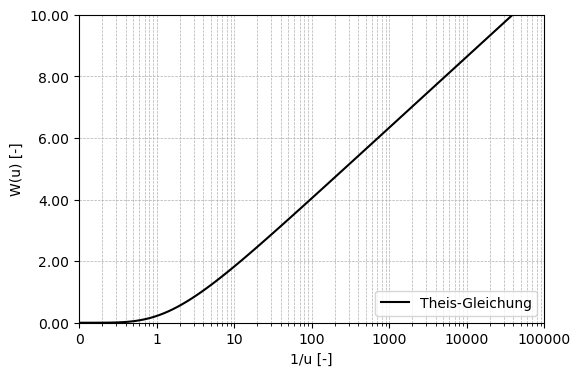

In [19]:
# calculate and plot Theis well function

# define values for 1/u
u = 1/np.logspace(-1, 5, num=100, base=10)

# define tolerance range (needed for solution of well equation) 
tol = 1e-12

# solve well equation (this is done by calling a function)
W = list(map(lambda u: wf.well_fxn(u,tol),u))

# visualize results
#  note that we look at a double log scale
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(1/u, W, '-', c='black', label='Theis-Gleichung')
ax.set_xlabel('1/u [-]')
ax.set_ylabel('W(u) [-]')
ax.set_xscale("log")
#ax.set_yscale("log")
ax.set_xlim([0.1, 100000])
ax.set_ylim([0.0, 10])
ax.xaxis.set_major_formatter(ticker.FuncFormatter(fmt_func_x))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(fmt_func_y))
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
#ax.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
ax.legend(loc='lower right')
plt.show()

## Cooper-Jacob-Methode mit Messdaten

Zuerst laden wir Daten eines Pumpversuchs ein. 
Diese bestehen aus der Pumprate, dem Abstand des Beobachtungsbrunnens zum Förderbrunnen, sowie der Zeit und der dazugehörigen Absenkung.

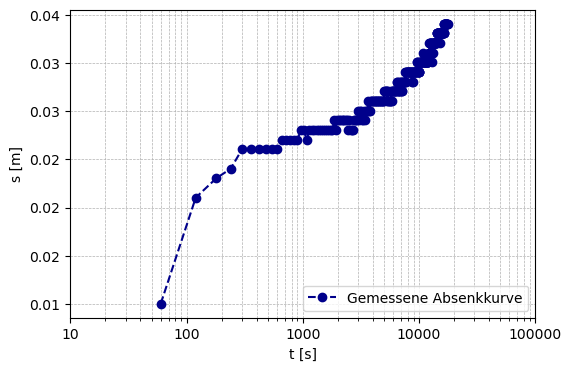

In [18]:
# load data from pumping test

# pumping rate and radius
Q = 0.0053 # [m³/s]
r = 40.95 # [m]
b = 15.2 # [m]

# load data
df = pd.read_excel('data/PV.xlsx', sheet_name='GWM')
df['Datum/Zeit'] = pd.to_datetime(df['Datum/Zeit'], format='%m/%d/%Y  %I:%M:%S %p')
t_obs = (df['Datum/Zeit'] - df['Datum/Zeit'][0]).dt.total_seconds()
s_obs = df["Wassersp, [muROK]"]

# time of third pumping test
mask = (t_obs > 6300) & (t_obs < 24000)
t_obs = t_obs[mask]
t_obs = t_obs - t_obs.iloc[0]
t_obs = t_obs[1:]
s_obs = s_obs[mask]
s_obs = s_obs - s_obs.iloc[0]
s_obs = s_obs[1:]

# Jacob correction
s_obs = s_obs / (1 - s_obs / b) # does not lead to a huge difference here
    
# visualize data
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t_obs, s_obs, 'o--', c='darkblue', label='Gemessene Absenkkurve')
ax.set_xlabel('t [s]')
ax.set_ylabel('s [m]')
ax.set_xscale("log")
#ax.set_yscale("log")
ax.set_xlim([10, 100000])
#ax.set_ylim([0, 0.05])
ax.xaxis.set_major_formatter(ticker.FuncFormatter(fmt_func_x))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(fmt_func_y))
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.legend(loc='lower right')
plt.show()